In [197]:
# モジュール
import numpy as np
import random
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
sys.setrecursionlimit(100000000)

In [225]:
# スペック部分
class spec:
    #通常2000回転やって収支を出す
    def __init__(self,a,b,c,d,e):
        self.kaitensuu = a #現在の累計回転数
        self.all = b # 累計回転
        self.balls = c # 現在の出玉
        self.border = d # 1kあたりの回転
        self.limit = e
        self.max = 0
        self.min = 0

    def normal(self):
        limit = self.limit #回転数上限
        cost = 250 / self.border # 1回転あたりのコスト
        while True:
            if self.all >= limit:
                return self.balls
            x = random.random()
            self.kaitensuu += 1
            self.balls -= cost
            if self.balls < self.min:
                self.min = self.balls
            self.all += 1

            if x <= 1/199.9*0.5:
                self.kaitensuu = 0
                self.balls += 280
                self.normal()
            elif x <= 1/199.9*(0.5+0.24):
                self.kaitensuu = 0
                self.balls += 1120
                self.normal()
            elif x <= 1/199.9*(0.5+0.24+0.255):
                self.kaitensuu = 0
                self.balls += 1120
                self.rush(135)
            elif x <= 1/199.9:
                self.kaitensuu = 0
                self.balls += 280
                self.rush(135)

    def rush(self, kaiten):

        if self.balls > self.max:
            self.max = self.balls
        # 1/78の幾何分布
        x = np.random.geometric(1/78)
        if x > kaiten:
            self.normal()
        else:
            furiwake = random.random()
            q = 1/3.4
            if furiwake <= q **5:
                self.balls += 7000
                self.rush(135)
            elif furiwake <= q**5 + 5*q**4*(1-q):
                self.balls += 5600
                self.rush(135)
            elif furiwake <= q**5 + 5*q**4*(1-q) + 10*q**3*(1-q)**2:
                self.balls += 4200
                self.rush(135)
            elif furiwake <= q**5 + 5*q**4*(1-q) + 10*q**3*(1-q)**2 + 10*q**2*(1-q)**3:
                self.balls += 2800
                self.rush(135)
            elif furiwake <= q**5 + 5*q**4*(1-q) + 10*q**3*(1-q)**2 + 10*q**2*(1-q)**3 + 5*q*(1-q)**4:
                self.balls += 1400
                self.rush(135)
            elif furiwake <= 1 - (1-q)**5/2:
                self.rush(135)
            else:
                self.rush(kaiten - x)


In [199]:
(1-(1/199.9*0.5+1/199.9 * 0.24+1/199.9 * 0.255))*199.9

198.905

In [200]:
results = []
for i in tqdm(range(10)):
    instance = spec(0, 0, 0, 20, 1000000)
    a = instance.normal()
    results.append(1000000*1000/a/4)
print(np.mean(results))
np.float64(16.76533978508055)

100%|██████████| 10/10 [00:01<00:00,  7.78it/s]

106.90333664619621


np.float64(16.76533978508055)

In [ ]:
result = []
for i in tqdm(range(10000)):
    instance = spec(0, 0, 0, 21, 2000) # 初期化
    balls = instance.normal()
    result.append(balls)


 35%|███▌      | 3533/10000 [00:00<00:01, 4419.32it/s]


KeyboardInterrupt: 

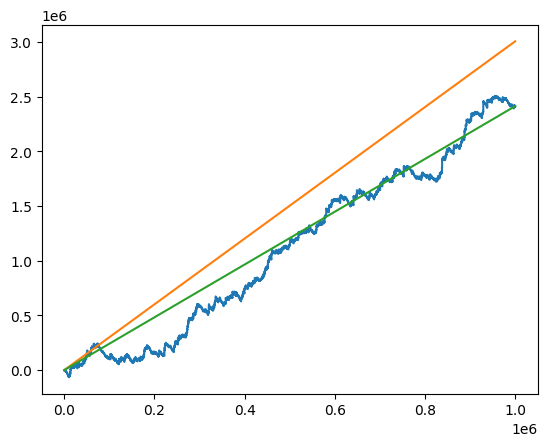

In [307]:
result = []
border = 16.76533978508055
kaiten = 21
for _ in range(1000000):
    instance = spec(0, 0, 0, kaiten, 1) # 初期化
    balls = instance.normal()
    result.append(balls)
# ballsの累積plot
balls_history = np.cumsum(result)
plt.plot(balls_history)
# 250/border * xの直線プロット
slope = (250 * kaiten/border - 250)/kaiten
slope_sample = balls_history[-1]/1000000
plt.plot(np.arange(1, 1000001), slope * np.arange(1, 1000001))
plt.plot(np.arange(1, 1000001), slope_sample * np.arange(1, 1000001))
plt.show()

In [312]:
result = []
for i in tqdm(range(10000)):
    instance = spec(0, 0, 0, 16.76533978508055, 2000) # 初期化
    balls = instance.normal()
    result.append(balls)


100%|██████████| 10000/10000 [00:02<00:00, 4193.00it/s]


平均収支:  7.1502724624693395
標準偏差:  23129.72429362145
最大値:  167576.56627245343
最小値:  -29543.433727536896
5%点:  -26183.433727537024
95%点:  43816.56627246408
勝率:  0.4112
50%点:  -5183.433727538033


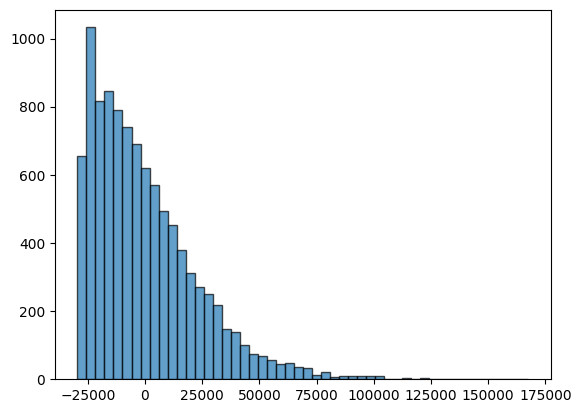

In [313]:
print("平均収支: ", np.mean(result))
print("標準偏差: ", np.std(result))
print("最大値: ", np.max(result))
print("最小値: ", np.min(result))
print("5%点: ", np.percentile(result, 5))
print("95%点: ", np.percentile(result, 95))
print("勝率: ", np.sum(np.array(result)>0)/len(result))
alpha = 50
print(f'{alpha}%点: ', np.percentile(result, alpha))
plt.hist(np.array(result), bins=50, edgecolor='black', alpha=0.7)
plt.show()

In [204]:
# LTの期待出玉
p = 1 / 3.4
q = 1 / 78.0

In [205]:
r = 1 - (1- 1/78* (1-(1-p) ** 5 / 2)) ** 135
r

0.7957514169183058

In [206]:
1/(1-r) - 1

3.8959947966935244

In [207]:
rb = 140
furiwake = np.array([50,40,30,20,10,0])
kakuritu = np.array([p**5,5*p**4*(1-p),10*p**3*(1-p)**2,10*p**2*(1-p)**3,5*p*(1-p)**4,(1-p)**5/2])
kakuritu_sum = np.sum(kakuritu)
kakuritu = kakuritu / kakuritu_sum
kakuritu

array([0.00241231, 0.02894767, 0.13894882, 0.33347717, 0.40017261,
       0.09604143])

In [208]:
kitai_lt = rb * np.dot(furiwake,kakuritu) * (1/(1-r) - 1)
kitai_lt

np.float64(8791.52994965606)

In [209]:
# 1回転の期待を計算
kakuritu = 1/ 199.95
furiwake = np.array([0.5,0.24,0.255,0.005]) # チ，通，LT，チLT
dedama = np.array([2*rb,8*rb,8*rb+kitai_lt,2*rb+kitai_lt])
kitai = 1/199.95*np.dot(furiwake,dedama)
kitai

np.float64(14.911716863768822)

In [210]:
zugara = np.array([0.51,0.48])/0.99
no_zugara = [0.99,0.01]
kitai = 1/399.9 * (np.dot(zugara,[8*rb+kitai_lt,8*rb]) + np.dot(no_zugara,[2*rb,2*rb+kitai_lt]))
border = 250/kitai
border


np.float64(16.615739781393238)

In [211]:
border = 250/kitai
border

np.float64(16.615739781393238)